# SEWA Rural Fingernail Anemia Classification  Data Preparation Module

Prepares a 4-class (severity-graded) fingernail anemia dataset — a
large-scale clinical supplement to the Nail-Anemia category, sourced
from a real-world rural healthcare screening study in India.

**Dataset:** [SEWA Rural Anemia Survey Dataset — HuggingFace (gated)](https://huggingface.co/datasets/sewa-rural-care/anemia-survey-dataset)

Collected by SEWA Rural (Society for Education, Welfare and Action,
Gujarat, India) as part of a published study protocol:
*"Screening for anemia using multi-modal machine learning models on
smartphones"* (medRxiv, April 2025,
10.1101/2025.04.10.25325591). Ethics approval: SR/IEC/2023/03/01.
License: CC BY-NC 4.0 (non-commercial research use, attribution required,
no redistribution outside HuggingFace per the Data Use Policy).

**Note:** This dataset also contains Conjunctiva, Tongue, and PPG-signal
modalities for the same 5,872 participants, which were intentionally
NOT extracted here (out of scope for the Nail category)  handed off
to the team member responsible for Eye/Tongue categories.

## What this notebook does

1. **Gated access setup**  requested and received access via
   HuggingFace, authenticated using a Kaggle Secret-stored token.

2. **List available shards**  this dataset is stored as 734 parquet shards (8 participants each, ~5,872 total).                Selected the first 125 shards (~1,000 participants) as the target sample.

3. **Column-selective extraction**  used `pyarrow` directly (not
   `load_dataset()`) to read only the needed columns per shard
   (`patient_uuid`, `hemoglobin_category`, haemoglobin values, and the
   two fingernail image columns), avoiding a schema-casting bug in the
   `datasets` library and avoiding downloading the large `ppg_frames`
   column (~900 frames/patient) entirely.

4. **Extracted both fingernail modalities per patient** 
   `fingernails_open` (fingers spread) and `fingernails_closed`
   (fingers curled), saved as JPGs into `hemoglobin_category` folders.

5. **Disk management**  each shard's HuggingFace cache (blobs +
   symlinks) was deleted immediately after processing to avoid
   exceeding Kaggle's disk quota (a shard is ~1.1GB due to the bundled
   PPG data, even though only 2 small image columns are kept). The
   extraction loop is resume-safe (skips already-saved files), since
   an earlier run hit a disk-space crash partway through.

6. **Dropped 2 "unknown" records**  patients missing both ground-truth
   haemoglobin sources (`survey_haemoglobin` and `cbc_hgb_g_dl`).

7. **Artifact check**  0% black-border artifact across all 4 classes.

**Final output:** `df_final_clean` (1,974 images, ~1,000 patients) with
`path` column at `/kaggle/working/sewa_rural_fingernails/`, saved as
`/kaggle/working/sewa_rural_fingernails_final.csv`.

**For future runs:** this notebook re-downloads shards from HuggingFace
each time it's run fresh (Kaggle's `/kaggle/working` is empty on a new
session)  this is expected and takes significant time/bandwidth.
Prefer using this notebook's **committed Output** (via "Save & Run All")
rather than re-running from scratch, where possible.

In [3]:
#Step 0 — HuggingFace Gated Access Setup (Token via Kaggle Secrets)
!pip install datasets huggingface_hub --quiet

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

from huggingface_hub import login
login(token=HF_TOKEN)

from datasets import load_dataset

DATASET_META = {
    "dataset_name": "SEWA Rural Anemia Survey Dataset (Fingernails subset)",
    "dataset_url": "https://huggingface.co/datasets/sewa-rural-care/anemia-survey-dataset",
    "hf_path": "sewa-rural-care/anemia-survey-dataset",
    "surface": "Nail"
}

ds = load_dataset(DATASET_META["hf_path"], split="train", streaming=True)
print(ds)
print(ds.features)

README.md:   0%|          | 0.00/25.5k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/734 [00:00<?, ?it/s]

IterableDataset({
    features: ['patient_uuid', 'survey_eligibility_comment', 'survey_eligible', 'survey_not_eligible_reason', 'survey_clinical_setting_type', 'survey_visit_reason', 'survey_service_attended', 'survey_smoking_history', 'survey_lack_of_energy', 'survey_breath_shortness', 'survey_fast_heart_beat', 'survey_losing_weight', 'survey_chest_pain', 'survey_dizziness', 'survey_headache', 'survey_leg_cramp', 'survey_brittle_nail_hair', 'survey_adult_other_symptom', 'survey_child_looks_pale', 'survey_child_losing_weight', 'survey_child_tired', 'survey_child_breathing_difficulty', 'survey_child_other_symptom', 'survey_data_collection_place', 'survey_data_collection_location', 'survey_data_collection_time', 'survey_data_collection_season', 'survey_light_intensity', 'survey_infant_height', 'survey_infant_weight', 'survey_systolic_bp', 'survey_diastolic_bp', 'survey_skin_tone_l', 'survey_skin_tone_b', 'survey_nail_polish_or_henna', 'survey_nail_examination', 'survey_other_nail_examina

In [15]:
#Step 1 — List Dataset Shards (Verify Schema/Columns)
from huggingface_hub import list_repo_files

all_files = list_repo_files("sewa-rural-care/anemia-survey-dataset", repo_type="dataset")
shard_files = sorted([f for f in all_files if f.startswith("data/shard_") and f.endswith(".parquet")])
print(f"Total shards available: {len(shard_files)}")
print(f"Sample shard filenames: {shard_files[:3]}")

# verify schema/columns using the streaming dataset (lightweight, no download)
from datasets import load_dataset
ds = load_dataset("sewa-rural-care/anemia-survey-dataset", split="train", streaming=True)
print(f"\nColumns available: {list(ds.features.keys())}")

Total shards available: 734
Sample shard filenames: ['data/shard_00001.parquet', 'data/shard_00002.parquet', 'data/shard_00003.parquet']


README.md:   0%|          | 0.00/25.5k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/734 [00:00<?, ?it/s]


Columns available: ['patient_uuid', 'survey_eligibility_comment', 'survey_eligible', 'survey_not_eligible_reason', 'survey_clinical_setting_type', 'survey_visit_reason', 'survey_service_attended', 'survey_smoking_history', 'survey_lack_of_energy', 'survey_breath_shortness', 'survey_fast_heart_beat', 'survey_losing_weight', 'survey_chest_pain', 'survey_dizziness', 'survey_headache', 'survey_leg_cramp', 'survey_brittle_nail_hair', 'survey_adult_other_symptom', 'survey_child_looks_pale', 'survey_child_losing_weight', 'survey_child_tired', 'survey_child_breathing_difficulty', 'survey_child_other_symptom', 'survey_data_collection_place', 'survey_data_collection_location', 'survey_data_collection_time', 'survey_data_collection_season', 'survey_light_intensity', 'survey_infant_height', 'survey_infant_weight', 'survey_systolic_bp', 'survey_diastolic_bp', 'survey_skin_tone_l', 'survey_skin_tone_b', 'survey_nail_polish_or_henna', 'survey_nail_examination', 'survey_other_nail_examination', 'surv

In [16]:
#Step 2 — Disk Space Check (Pre-Run Baseline)
import shutil

total, used, free = shutil.disk_usage("/kaggle/working")
print(f"Disk space before extraction:")
print(f"  Total: {total/1e9:.1f}GB")
print(f"  Used:  {used/1e9:.1f}GB")
print(f"  Free:  {free/1e9:.1f}GB")

# clear any stale HuggingFace cache from a prior run, just in case
shutil.rmtree("/root/.cache/huggingface/hub", ignore_errors=True)

total, used, free = shutil.disk_usage("/kaggle/working")
print(f"\nDisk space after cache cleanup:")
print(f"  Free: {free/1e9:.1f}GB")

Disk space before extraction:
  Total: 21.0GB
  Used:  0.1GB
  Free:  20.9GB

Disk space after cache cleanup:
  Free: 20.9GB


In [7]:
#Step 3 — Extract Fingernail Images (Column-Selective, Resume-Safe, Disk-Managed Loop)
from huggingface_hub import list_repo_files, hf_hub_download
import pyarrow.parquet as pq
import io
from PIL import Image
from pathlib import Path
import pandas as pd
import shutil

OUTPUT_DIR = Path("/kaggle/working/sewa_rural_fingernails")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_files = list_repo_files("sewa-rural-care/anemia-survey-dataset", repo_type="dataset")
shard_files = sorted([f for f in all_files if f.startswith("data/shard_") and f.endswith(".parquet")])
print(f"Total shards available: {len(shard_files)}")

keep_cols = ["patient_uuid", "hemoglobin_category", "survey_haemoglobin",
             "cbc_hgb_g_dl", "image_fingernails_open", "image_fingernails_closed"]

TARGET_SHARDS = 125
records = []

existing = list(OUTPUT_DIR.rglob("*.jpg"))
print(f"Already have {len(existing)} images saved from prior run")

for shard_idx, shard_file in enumerate(shard_files[:TARGET_SHARDS]):
    try:
        local_path = hf_hub_download(
            repo_id="sewa-rural-care/anemia-survey-dataset",
            repo_type="dataset",
            filename=shard_file
        )
        table = pq.read_table(local_path, columns=keep_cols)
        df_shard = table.to_pandas()

        for _, row in df_shard.iterrows():
            uuid = row["patient_uuid"]
            hb_cat = row["hemoglobin_category"]
            for modality in ["fingernails_open", "fingernails_closed"]:
                img_data = row[f"image_{modality}"]
                if img_data is None or img_data.get("bytes") is None:
                    continue
                dest = OUTPUT_DIR / (hb_cat or "unknown") / f"{uuid}_{modality}.jpg"
                if dest.exists():
                    continue
                try:
                    img = Image.open(io.BytesIO(img_data["bytes"]))
                    if img.mode != "RGB":
                        img = img.convert("RGB")
                    dest.parent.mkdir(parents=True, exist_ok=True)
                    img.save(dest, "JPEG")
                    records.append({"patient_uuid": uuid, "modality": modality,
                                     "hemoglobin_category": hb_cat,
                                     "survey_haemoglobin": row["survey_haemoglobin"],
                                     "cbc_hgb_g_dl": row["cbc_hgb_g_dl"],
                                     "path": str(dest)})
                except Exception as e:
                    print(f"Failed {uuid}/{modality}: {e}")

        shutil.rmtree("/root/.cache/huggingface/hub", ignore_errors=True)

    except Exception as e:
        print(f"Shard {shard_idx} ({shard_file}) failed: {e}")
        continue

    if (shard_idx + 1) % 10 == 0:
        total, used, free = shutil.disk_usage("/kaggle/working")
        print(f"Processed {shard_idx+1}/{TARGET_SHARDS} shards, {len(records)} new images, disk free: {free/1e9:.1f}GB")

print(f"\nDone. Total NEW images saved this run: {len(records)}")
all_images = list(OUTPUT_DIR.rglob("*.jpg"))
print(f"Total images on disk (including prior runs): {len(all_images)}")

Total shards available: 734
Already have 1204 images saved from prior run


data/shard_00001.parquet: reconstructing file:   0%|          |  0.00B /  982MB            

data/shard_00001.parquet: downloading bytes:           |  0.00B            

data/shard_00002.parquet: reconstructing file:   0%|          |  0.00B /  963MB            

data/shard_00002.parquet: downloading bytes:           |  0.00B            

...

data/shard_00124.parquet: reconstructing file:   0%|          |  0.00B /  897MB            

data/shard_00124.parquet: downloading bytes:           |  0.00B            

data/shard_00125.parquet: reconstructing file:   0%|          |  0.00B /  883MB            

data/shard_00125.parquet: downloading bytes:           |  0.00B            


Done. Total NEW images saved this run: 772
Total images on disk (including prior runs): 1976


In [12]:
#Step 4 — Drop “Unknown” records
df_final_clean = df_final[df_final["hemoglobin_category"] != "unknown"].reset_index(drop=True)
print(f"After dropping unknown: {len(df_final_clean)} images")
print(df_final_clean["hemoglobin_category"].value_counts())

df_final_clean.to_csv("/kaggle/working/sewa_rural_fingernails_final.csv", index=False)
print("Saved (updated)")

After dropping unknown: 1974 images
hemoglobin_category
moderate_anemia    886
mild_anemia        502
normal             296
severe_anemia      290
Name: count, dtype: int64
Saved (updated)


In [17]:
#Step 5 — Artifact Check
import cv2
import numpy as np

def has_box_artifact(img_path, dark_thresh=15, border_frac=0.05):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    top, bottom = gray[:bh, :], gray[-bh:, :]
    left, right = gray[:, :bw], gray[:, -bw:]
    border_pixels = np.concatenate([top.ravel(), bottom.ravel(), left.ravel(), right.ravel()])
    return (border_pixels < dark_thresh).mean() > 0.5

all_images = list(OUTPUT_DIR.rglob("*.jpg"))
final_records = []
for img_path in all_images:
    cls = img_path.parent.name
    final_records.append({"path": str(img_path), "hemoglobin_category": cls,
                           "filename": img_path.name})

df_final = pd.DataFrame(final_records)

# drop "unknown" category before artifact check / summary (per Step 4)
df_final = df_final[df_final["hemoglobin_category"] != "unknown"].reset_index(drop=True)

df_final["box_artifact"] = df_final["path"].apply(has_box_artifact)

summary = df_final.groupby("hemoglobin_category")["box_artifact"].agg(["sum", "count"])
summary["pct"] = (summary["sum"] / summary["count"] * 100).round(1)
print(summary)

                     sum  count  pct
hemoglobin_category                 
mild_anemia            0    502  0.0
moderate_anemia        0    886  0.0
normal                 0    296  0.0
severe_anemia          0    290  0.0


In [18]:
#Step 6 — Final Summary + Save CSV
print(f"Final dataset: {len(df_final)} images across {df_final['hemoglobin_category'].nunique()} classes")
print(df_final["hemoglobin_category"].value_counts())
print(f"\nImbalance ratio: {df_final['hemoglobin_category'].value_counts().max() / df_final['hemoglobin_category'].value_counts().min():.2f}x")

output_csv = "/kaggle/working/sewa_rural_fingernails_final.csv"
df_final.to_csv(output_csv, index=False)
print(f"\nSaved -> {output_csv}")

# full table view (like Notebook 1's display_df)
display_df = df_final[["hemoglobin_category", "filename", "box_artifact", "path"]].copy()
display_df = display_df.sort_values(["hemoglobin_category", "filename"]).reset_index(drop=True)
pd.set_option("display.max_colwidth", 60)
display_df

Final dataset: 1974 images across 4 classes
hemoglobin_category
moderate_anemia    886
mild_anemia        502
normal             296
severe_anemia      290
Name: count, dtype: int64

Imbalance ratio: 3.06x

Saved -> /kaggle/working/sewa_rural_fingernails_final.csv


,hemoglobin_category,filename,box_artifact,path
0,mild_anemia,00047e5d-eacd-4b17-8575-39e4181ca498_fingernails_closed.jpg,False,/kaggle/working/sewa_rural_fingernails/mild_anemia/00047...
1,mild_anemia,00047e5d-eacd-4b17-8575-39e4181ca498_fingernails_open.jpg,False,/kaggle/working/sewa_rural_fingernails/mild_anemia/00047...
2,mild_anemia,0024e2a2-c4f2-4c36-bf00-52dbae7d2b03_fingernails_closed.jpg,False,/kaggle/working/sewa_rural_fingernails/mild_anemia/0024e...
3,mild_anemia,0024e2a2-c4f2-4c36-bf00-52dbae7d2b03_fingernails_open.jpg,False,/kaggle/working/sewa_rural_fingernails/mild_anemia/0024e...
4,mild_anemia,009c4042-52fb-4453-8078-83cb19fe9906_fingernails_closed.jpg,False,/kaggle/working/sewa_rural_fingernails/mild_anemia/009c4...
...,...,...,...,...
1969,severe_anemia,2cb2e865-e5c8-4e77-8fff-f7ad8bb606ab_fingernails_open.jpg,False,/kaggle/working/sewa_rural_fingernails/severe_anemia/2cb...
1970,severe_anemia,2cb8093e-1d1f-40d3-bca3-997fe3eb992e_fingernails_closed.jpg,False,/kaggle/working/sewa_rural_fingernails/severe_anemia/2cb...
1971,severe_anemia,2cb8093e-1d1f-40d3-bca3-997fe3eb992e_fingernails_open.jpg,False,/kaggle/working/sewa_rural_fingernails/severe_anemia/2cb...
1972,severe_anemia,2cf03882-6de0-4ee5-babe-939627928e2d_fingernails_closed.jpg,False,/kaggle/working/sewa_rural_fingernails/severe_anemia/2cf...


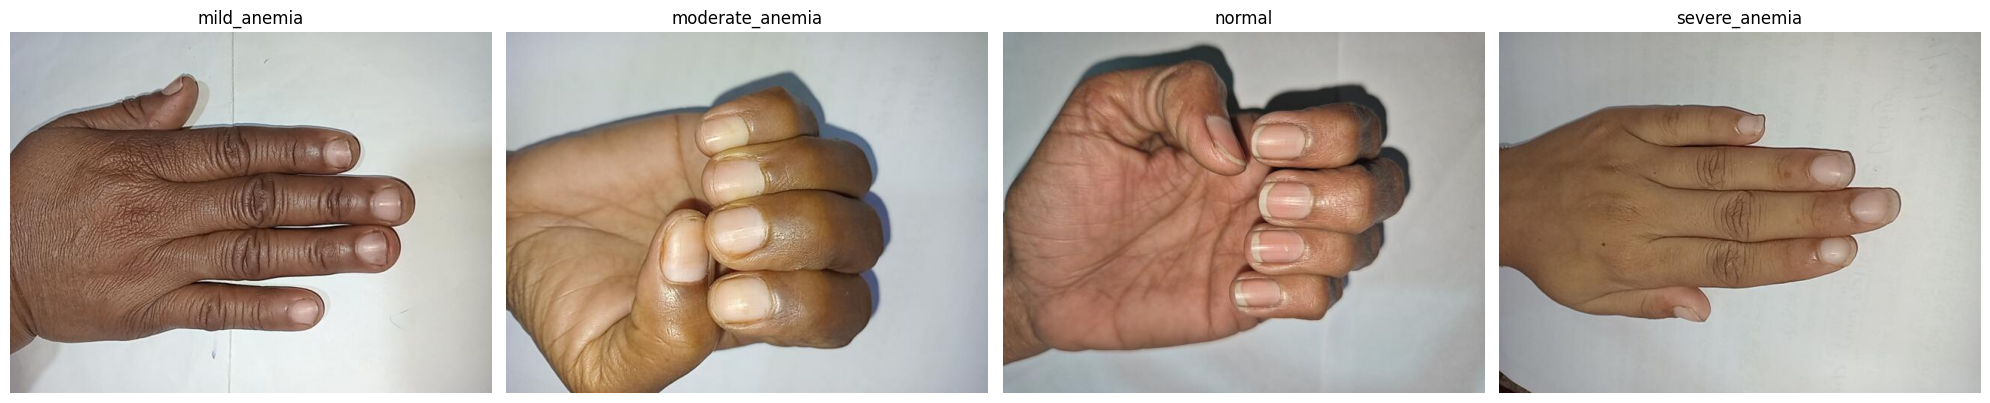

In [19]:
#Step 7 — Random Sample Viewer
import matplotlib.pyplot as plt

classes = sorted(df_final_clean["hemoglobin_category"].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))

for ax, cls in zip(axes, classes):
    row = df_final_clean[df_final_clean["hemoglobin_category"] == cls].sample(1).iloc[0]
    img = cv2.imread(row["path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()